In [1]:
!pip install -q torch torchvision torchaudio
!pip install -q scikit-learn seaborn matplotlib pandas pillow gradio

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import os
import random
import json
import copy
import time

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from PIL import Image


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [8]:
DATA_DIR = "./data"
dataset_full = datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="category",
    download=True
)

dataset_test = datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="test",
    target_types="category",
    download=True
)

print("Train+Validation images:", len(dataset_full))
print("Test images:", len(dataset_test))

100%|██████████| 792M/792M [00:21<00:00, 37.4MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 15.2MB/s]


Train+Validation images: 3680
Test images: 3669


In [9]:
classes = dataset_full.classes
NUM_CLASSES = len(classes)
print("Number of classes:", NUM_CLASSES)

for i, class_name in enumerate(classes):
    print(i, ":", class_name)

Number of classes: 37
0 : Abyssinian
1 : American Bulldog
2 : American Pit Bull Terrier
3 : Basset Hound
4 : Beagle
5 : Bengal
6 : Birman
7 : Bombay
8 : Boxer
9 : British Shorthair
10 : Chihuahua
11 : Egyptian Mau
12 : English Cocker Spaniel
13 : English Setter
14 : German Shorthaired
15 : Great Pyrenees
16 : Havanese
17 : Japanese Chin
18 : Keeshond
19 : Leonberger
20 : Maine Coon
21 : Miniature Pinscher
22 : Newfoundland
23 : Persian
24 : Pomeranian
25 : Pug
26 : Ragdoll
27 : Russian Blue
28 : Saint Bernard
29 : Samoyed
30 : Scottish Terrier
31 : Shiba Inu
32 : Siamese
33 : Sphynx
34 : Staffordshire Bull Terrier
35 : Wheaten Terrier
36 : Yorkshire Terrier


In [12]:
dataset_full

Dataset OxfordIIITPet
    Number of datapoints: 3680
    Root location: ./data

In [13]:
image, label = dataset_full[0]

print("Image type:", type(image))
print("Image size:", image.size)
print("Label:", label)
print("Class:", classes[label])

Image type: <class 'PIL.Image.Image'>
Image size: (394, 500)
Label: 0
Class: Abyssinian


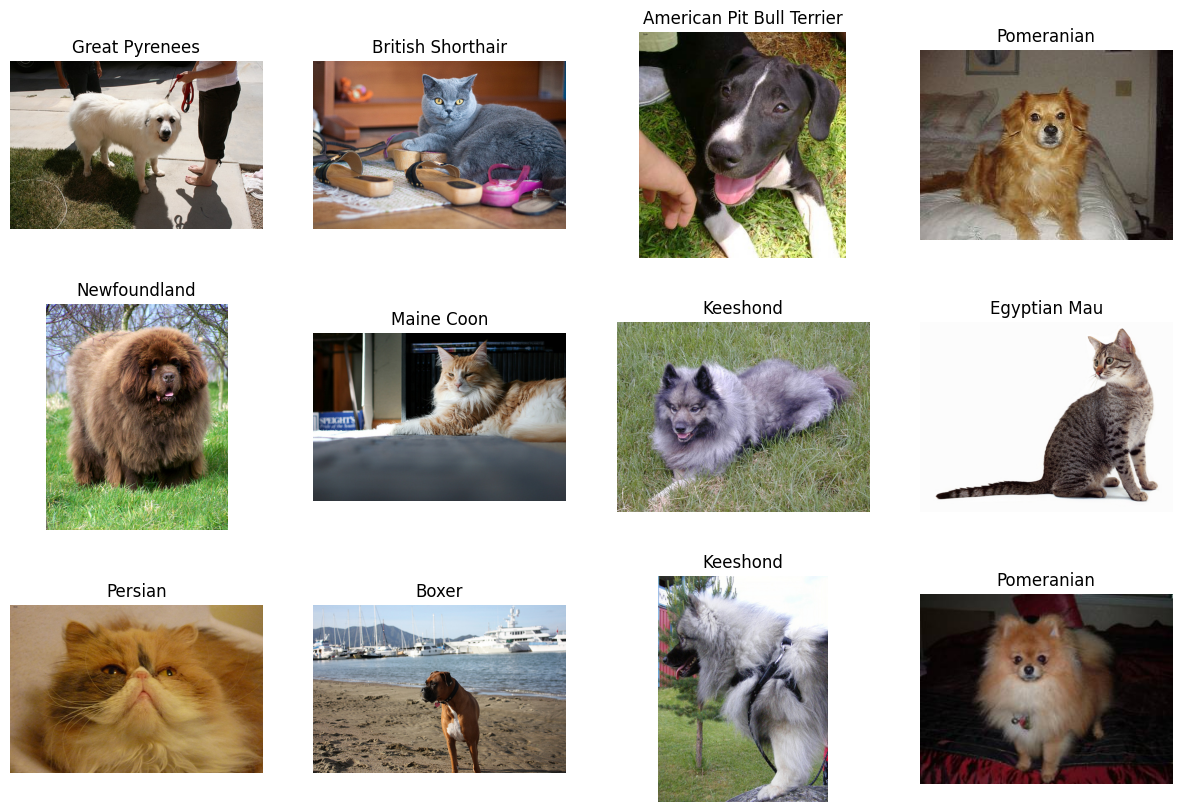

In [15]:
plt.figure(figsize=(15, 10))
random_indices = random.sample(range(len(dataset_full)),12)

for i, index in enumerate(random_indices):
    image, label = dataset_full[index]
    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(classes[label])
    plt.axis("off")
plt.show()

In [16]:
image_sizes = []
for i in range(len(dataset_full)):
    image, label = dataset_full[i]
    image_sizes.append(image.size)

image_sizes[:10]

[(394, 500),
 (450, 313),
 (500, 465),
 (500, 351),
 (600, 363),
 (500, 375),
 (1536, 1024),
 (500, 448),
 (500, 404),
 (282, 450)]

In [17]:
widths = [size[0] for size in image_sizes]
heights = [size[1] for size in image_sizes]

print("Minimum width:", min(widths))
print("Maximum width:", max(widths))

print("Minimum height:", min(heights))
print("Maximum height:", max(heights))

print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

Minimum width: 114
Maximum width: 3264
Minimum height: 108
Maximum height: 2606
Average width: 431.03342391304346
Average height: 383.4203804347826


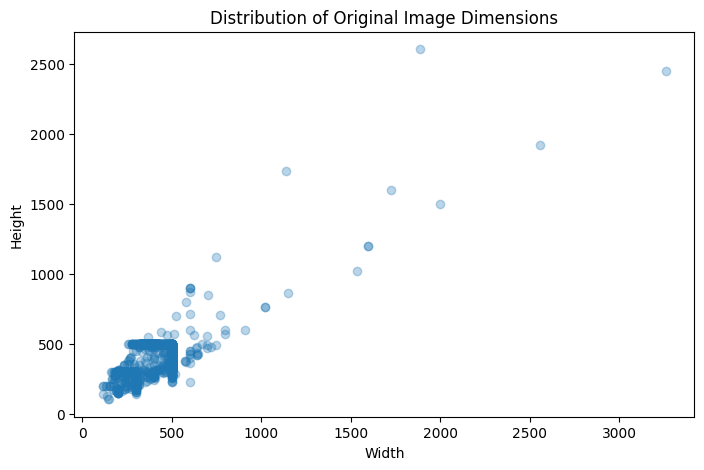

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Distribution of Original Image Dimensions")
plt.show()

Images have different sizes, so they need to be resized to the same size before training. This helps the model process them properly.

In [19]:
labels = [dataset_full[i][1] for i in range(len(dataset_full))]
class_counts = pd.Series(labels).value_counts().sort_index()
class_distribution = pd.DataFrame({
    "Class": classes,
    "Count": class_counts.values
})

class_distribution

,Class,Count
0,Abyssinian,100
1,American Bulldog,100
2,American Pit Bull Terrier,100
3,Basset Hound,100
4,Beagle,100
5,Bengal,100
6,Birman,100
7,Bombay,96
8,Boxer,100
9,British Shorthair,100


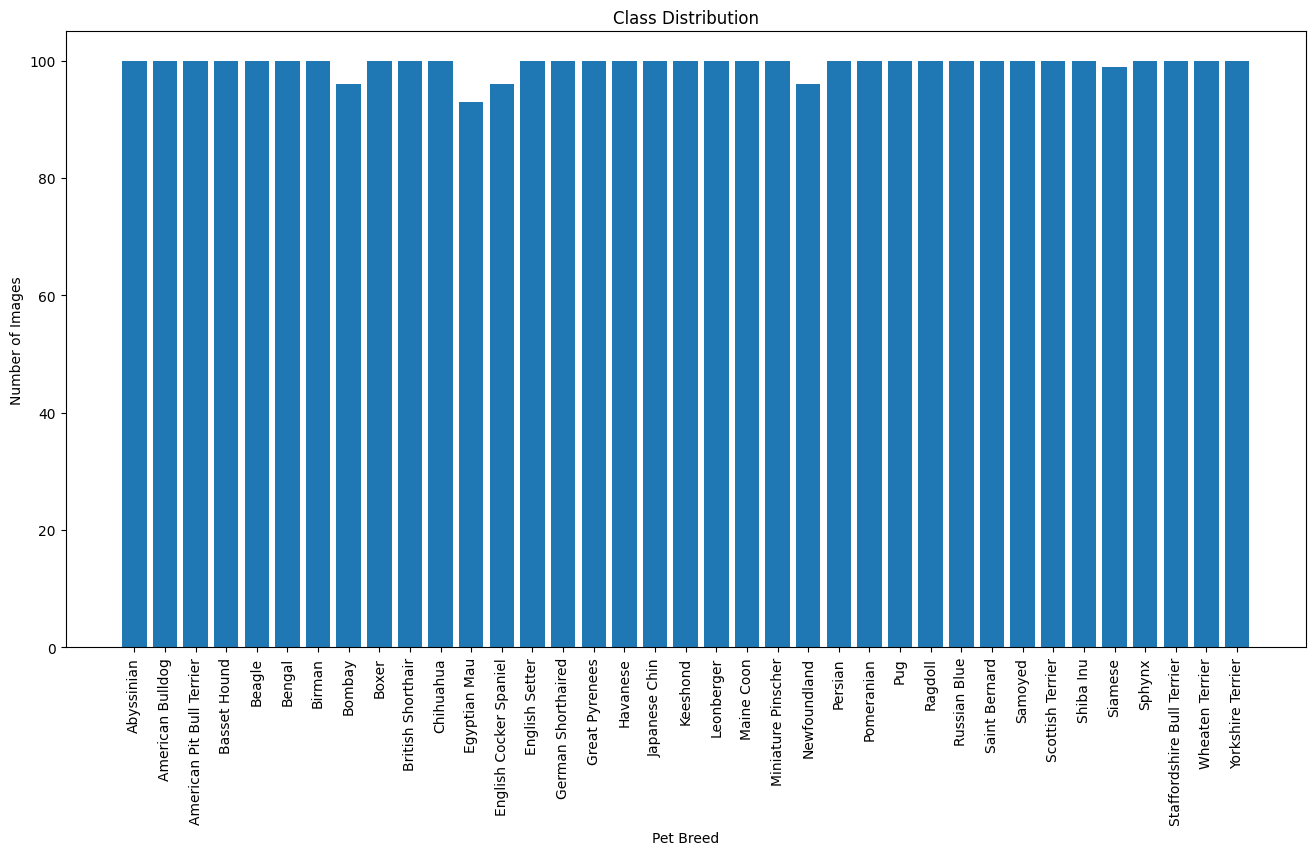

In [20]:
plt.figure(figsize=(16, 8))
plt.bar(
    class_distribution["Class"],
    class_distribution["Count"]
)

plt.xticks(rotation=90)
plt.xlabel("Pet Breed")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()

The dataset is balanced, with almost 100 images for each breed, so class imbalance is not a problem. The model’s mistakes are more likely due to its design or training.

In [23]:
data = []
for i in range(len(dataset_full)):
    image, label = dataset_full[i]

    data.append({
        "index": i,
        "class_id": label,
        "class_name": classes[label],
        "width": image.width,
        "height": image.height
    })
df = pd.DataFrame(data)



In [24]:
df

,index,class_id,class_name,width,height
0,0,0,Abyssinian,394,500
1,1,0,Abyssinian,450,313
2,2,0,Abyssinian,500,465
3,3,0,Abyssinian,500,351
4,4,0,Abyssinian,600,363
...,...,...,...,...,...
3675,3675,36,Yorkshire Terrier,500,334
3676,3676,36,Yorkshire Terrier,500,334
3677,3677,36,Yorkshire Terrier,500,334
3678,3678,36,Yorkshire Terrier,500,375


In [25]:
df.head()

,index,class_id,class_name,width,height
0,0,0,Abyssinian,394,500
1,1,0,Abyssinian,450,313
2,2,0,Abyssinian,500,465
3,3,0,Abyssinian,500,351
4,4,0,Abyssinian,600,363


In [26]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:")
print(df.duplicated().sum())
print("\nImage statistics:")
print(df[["width", "height"]].describe())

Dataset shape: (3680, 5)

Missing values:
index         0
class_id      0
class_name    0
width         0
height        0
dtype: int64

Duplicate rows:
0

Image statistics:
             width       height
count  3680.000000  3680.000000
mean    431.033424   383.420380
std     126.328303   116.833678
min     114.000000   108.000000
25%     333.000000   333.000000
50%     500.000000   375.000000
75%     500.000000   500.000000
max    3264.000000  2606.000000


In [27]:
indices = np.arange(len(dataset_full))
labels = np.array(labels)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=labels
)

print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))
print("Test images:", len(dataset_test))

Training images: 2944
Validation images: 736
Test images: 3669


In [30]:
train_labels = labels[train_indices]
print("Training class distribution:")
print(pd.Series(train_labels).value_counts().sort_index())

Training class distribution:
0     80
1     80
2     80
3     80
4     80
5     80
6     80
7     77
8     80
9     80
10    80
11    74
12    77
13    80
14    80
15    80
16    80
17    80
18    80
19    80
20    80
21    80
22    77
23    80
24    80
25    80
26    80
27    80
28    80
29    80
30    80
31    80
32    79
33    80
34    80
35    80
36    80
Name: count, dtype: int64


In [29]:
val_labels = labels[val_indices]
print("\nValidation class distribution:")
print(pd.Series(val_labels).value_counts().sort_index())


Validation class distribution:
0     20
1     20
2     20
3     20
4     20
5     20
6     20
7     19
8     20
9     20
10    20
11    19
12    19
13    20
14    20
15    20
16    20
17    20
18    20
19    20
20    20
21    20
22    19
23    20
24    20
25    20
26    20
27    20
28    20
29    20
30    20
31    20
32    20
33    20
34    20
35    20
36    20
Name: count, dtype: int64


In [31]:
IMG_SIZE = 224
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

In [33]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.8, 1.0)
    ),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2),
   transforms.ToTensor(),
    transforms.Normalize(mean=mean,std=std)
])

These transformations resize images and randomly change their angle, color, and direction. This helps the model learn from different images and improve its accuracy.

In [34]:
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean,std=std)
])

In [35]:
class SubsetWithTransform(Dataset):

    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        original_index = self.indices[idx]
        image, label = self.dataset[original_index]

        if self.transform:
            image = self.transform(image)

        return image, label

In [36]:
train_dataset = SubsetWithTransform(
    dataset_full,
    train_indices,
    transform=train_transform
)

val_dataset = SubsetWithTransform(
    dataset_full,
    val_indices,
    transform=test_transform
)

test_dataset = datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="test",
    target_types="category",
    transform=test_transform,
    download=False
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 2944
Validation: 736
Test: 3669


This code divides the images into training, validation, and testing sets. It applies different transformations and prints the number of images in each set as the produced output.

In [39]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
print("Dataloaders created")

Dataloaders created


In [40]:
images, labels_batch = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels_batch.shape)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


In [41]:
class CNN(nn.Module):

    def __init__(self, num_classes=37):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
           nn.Conv2d(3, 32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),


            nn.Conv2d(64, 128,kernel_size=3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

           nn.Conv2d(128, 256,kernel_size=3,padding=1),
           nn.BatchNorm2d(256),
           nn.ReLU(),
           nn.MaxPool2d(2),
           nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256,num_classes)
        )

    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [43]:
custom_model = CNN(num_classes=NUM_CLASSES)
custom_model = custom_model.to(device)

custom_model

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (

In [48]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(custom_model.parameters(), lr=0.001)

In [49]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs,1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = 100 * correct / total
    return epoch_loss, epoch_accuracy

In [50]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
         for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs,labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = 100 * correct / total
    return epoch_loss, epoch_accuracy

In [52]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    model_name="model"
):

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_accuracy = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        start_time = time.time()
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc = validate(
            model,
            val_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_weights = copy.deepcopy(model.state_dict())
        elapsed = time.time() - start_time

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_acc:.2f}% "
            f"Val Loss: {val_loss:.4f} "
            f"Val Acc: {val_acc:.2f}% "
            f"Time: {elapsed:.1f}s"
        )

    model.load_state_dict(best_weights)
    torch.save(
        model.state_dict(),
        f"{model_name}_best.pth"
    )

    print("\nBest Validation Accuracy:",f"{best_val_accuracy:.2f}%")
    return model, history

In [53]:
EPOCHS = 10

start_time = time.time()
custom_model, custom_history = train_model(
    custom_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=EPOCHS,
    model_name="custom_cnn"
)
custom_training_time = time.time() - start_time

print("Training time:",custom_training_time / 60,"minutes")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/10] Train Loss: 3.6180 Train Acc: 4.69% Val Loss: 3.5541 Val Acc: 4.48% Time: 788.8s
Epoch [2/10] Train Loss: 3.5169 Train Acc: 5.57% Val Loss: 3.4426 Val Acc: 8.42% Time: 680.2s
Epoch [3/10] Train Loss: 3.4541 Train Acc: 7.51% Val Loss: 3.4215 Val Acc: 7.74% Time: 689.8s
Epoch [4/10] Train Loss: 3.3865 Train Acc: 8.42% Val Loss: 3.3699 Val Acc: 10.05% Time: 680.3s
Epoch [5/10] Train Loss: 3.3428 Train Acc: 9.71% Val Loss: 3.3340 Val Acc: 9.65% Time: 680.5s
Epoch [6/10] Train Loss: 3.3100 Train Acc: 10.63% Val Loss: 3.3017 Val Acc: 11.82% Time: 689.1s
Epoch [7/10] Train Loss: 3.2528 Train Acc: 11.07% Val Loss: 3.3043 Val Acc: 11.41% Time: 692.4s
Epoch [8/10] Train Loss: 3.2406 Train Acc: 12.09% Val Loss: 3.2112 Val Acc: 13.32% Time: 698.6s
Epoch [9/10] Train Loss: 3.1701 Train Acc: 13.76% Val Loss: 3.3355 Val Acc: 11.01% Time: 701.9s
Epoch [10/10] Train Loss: 3.1240 Train Acc: 14.84% Val Loss: 3.1693 Val Acc: 16.30% Time: 702.8s

Best Validation Accuracy: 16.30%
Training time:

Training is very slow, and accuracy is still low after 10 epochs. The model is learning, but it needs more training or a better model to improve its accuracy.

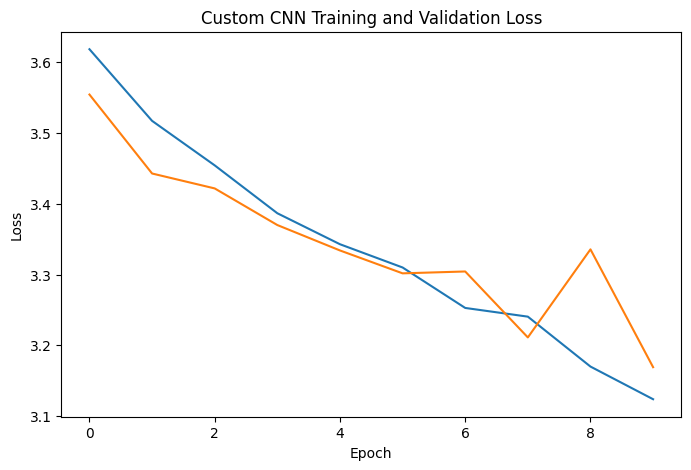

In [54]:
plt.figure(figsize=(8, 5))
plt.plot(custom_history["train_loss"],label="Training Loss")
plt.plot(custom_history["val_loss"],label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN Training and Validation Loss")
plt.show()

The model is learning well as both losses are going down. Validation loss changes a little, but overall the model is improving.

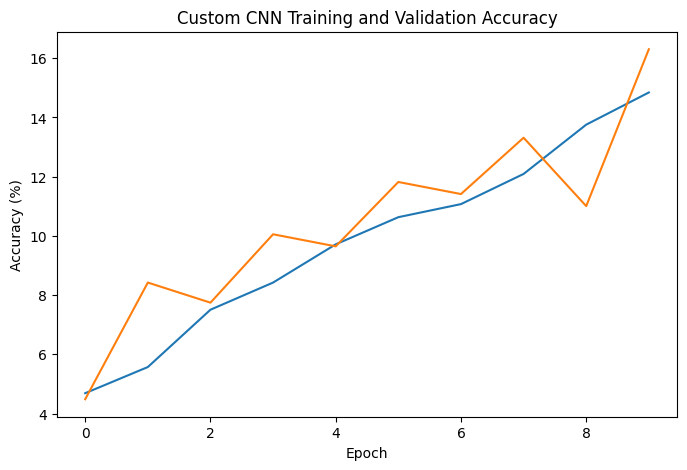

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(custom_history["train_acc"],label="Training Accuracy")
plt.plot(custom_history["val_acc"],label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Custom CNN Training and Validation Accuracy")
plt.show()

Training and validation accuracy generally increase over epochs, showing that the model is learning.

In [56]:
def get_predictions(
    model,
    loader,
    device
):

    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
       for images, labels in loader:
           images = images.to(device)
           outputs = model(images)
           predictions = torch.argmax(outputs,dim=1)
           all_predictions.extend(predictions.cpu().numpy())
           all_labels.extend(labels.numpy())

    return (np.array(all_labels),np.array(all_predictions))

In [57]:
y_true_custom, y_pred_custom = get_predictions(
    custom_model,
    test_loader,
    device
)

custom_accuracy = accuracy_score(y_true_custom,y_pred_custom)
custom_precision = precision_score(
    y_true_custom,
    y_pred_custom,
    average="macro",
    zero_division=0
)

custom_recall = recall_score(
    y_true_custom,
    y_pred_custom,
    average="macro",
    zero_division=0
)

custom_f1 = f1_score(
    y_true_custom,
    y_pred_custom,
    average="macro",
    zero_division=0
)

print(f"Accuracy : {custom_accuracy:.4f}")
print(f"Precision: {custom_precision:.4f}")
print(f"Recall   : {custom_recall:.4f}")
print(f"F1 Score : {custom_f1:.4f}")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy : 0.1177
Precision: 0.1215
Recall   : 0.1181
F1 Score : 0.0960


In [60]:
report = classification_report(
    y_true_custom,
    y_pred_custom,
    target_names=classes,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Abyssinian,0.173913,0.081633,0.111111,98.000000
American Bulldog,0.026316,0.020000,0.022727,100.000000
American Pit Bull Terrier,0.000000,0.000000,0.000000,100.000000
Basset Hound,0.053191,0.050000,0.051546,100.000000
Beagle,0.000000,0.000000,0.000000,100.000000
Bengal,0.154472,0.570000,0.243070,100.000000
Birman,0.138462,0.090000,0.109091,100.000000
Bombay,0.191304,0.250000,0.216749,88.000000
Boxer,0.050000,0.060606,0.054795,99.000000
British Shorthair,0.134615,0.070000,0.092105,100.000000


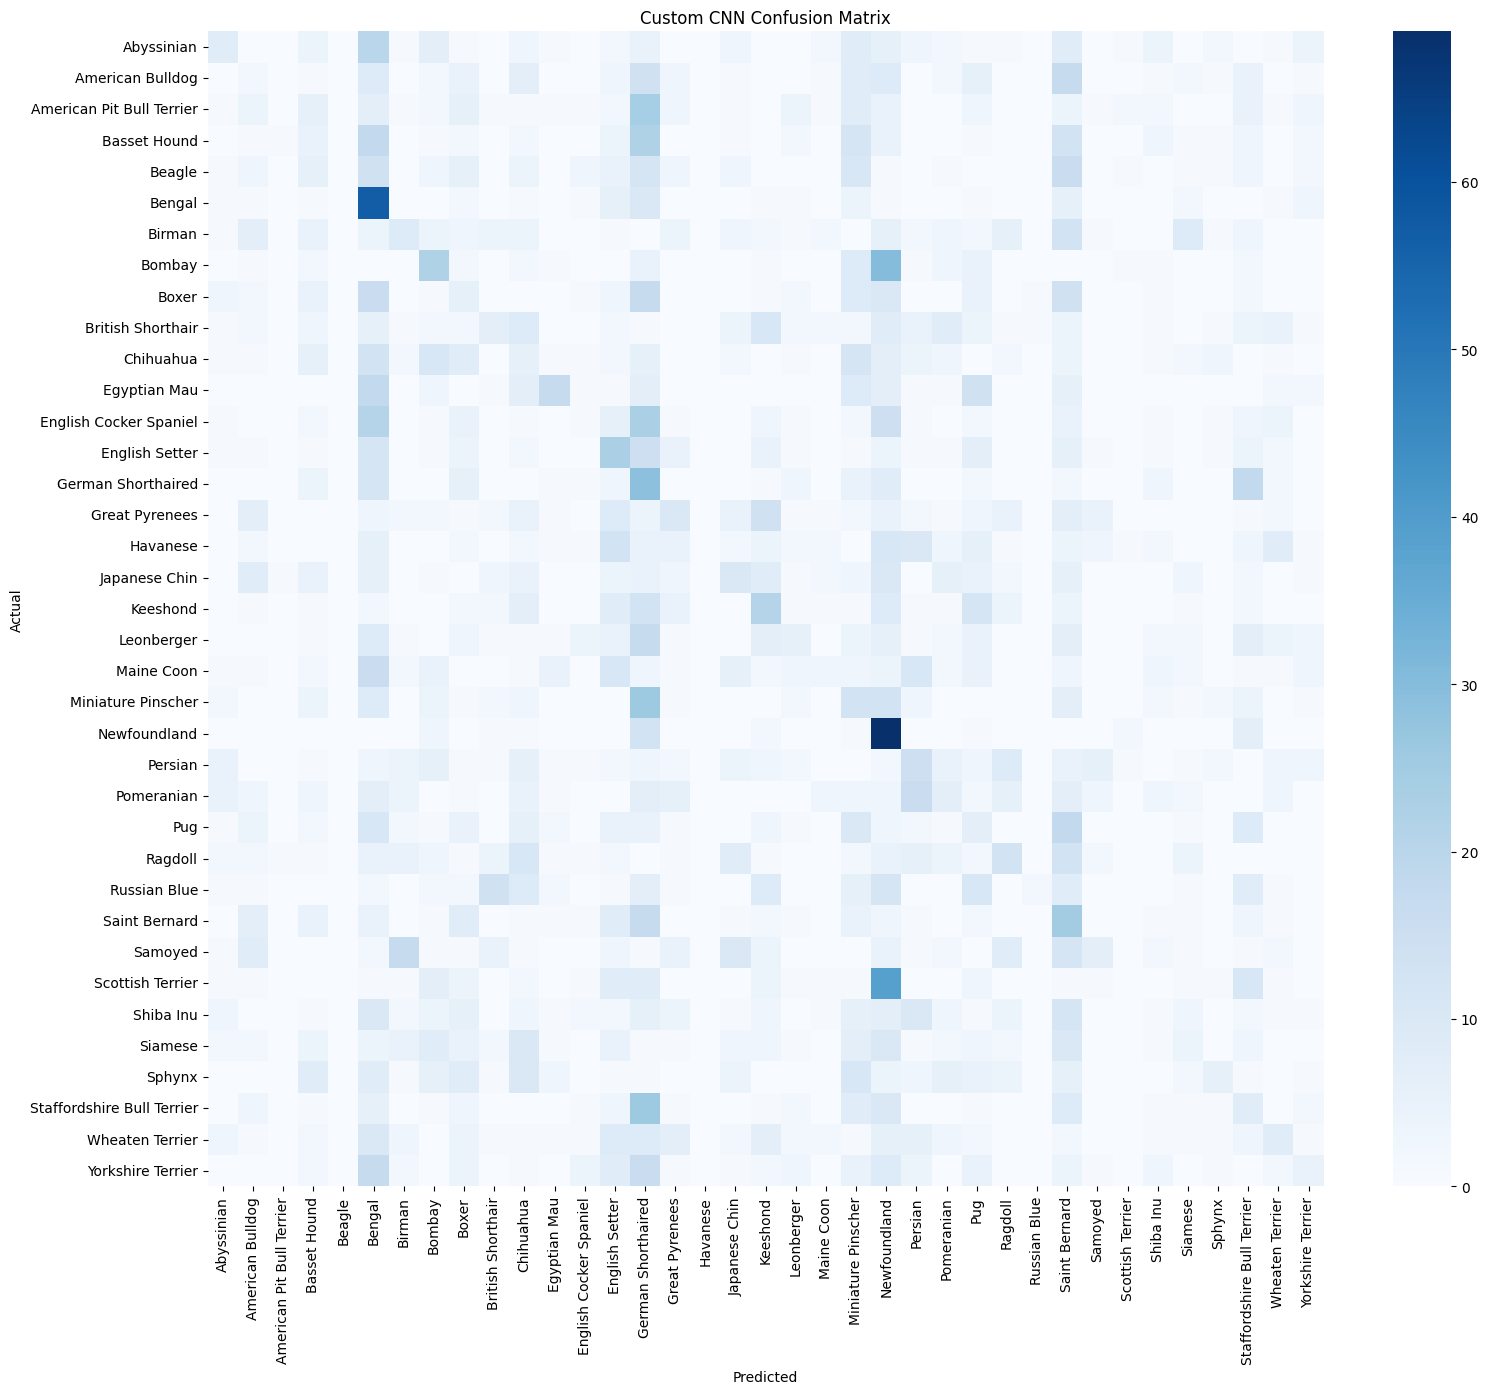

In [103]:
cm = confusion_matrix(y_true_custom, y_pred_custom)
plt.figure(figsize=(18, 15))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Custom CNN Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

The Custom CNN correctly predicts some dog breeds but makes many mistakes between different breeds. Its predictions are less accurate and more spread out across classes.

In [61]:
weights = models.ResNet18_Weights.DEFAULT
resnet_model = models.resnet18(weights=weights)
print(resnet_model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 134MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [62]:
for param in resnet_model.parameters():
    param.requires_grad = False

In [63]:
resnet_model.fc = nn.Linear(resnet_model.fc.in_features,NUM_CLASSES)
resnet_model = resnet_model.to(device)
print(resnet_model.fc)

Linear(in_features=512, out_features=37, bias=True)


In [64]:
criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001
)

In [65]:
start_time = time.time()

resnet_model, resnet_history = train_model(
    resnet_model,
    train_loader,
    val_loader,
    criterion_resnet,
    optimizer_resnet,
    device,
    epochs=5,
    model_name="resnet18_feature_extractor"
)
feature_extraction_time = time.time() - start_time
print("Feature extraction training time:",feature_extraction_time / 60, "minutes")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/5] Train Loss: 2.2461 Train Acc: 49.22% Val Loss: 1.1933 Val Acc: 76.77% Time: 423.2s
Epoch [2/5] Train Loss: 0.9744 Train Acc: 80.71% Val Loss: 0.7758 Val Acc: 81.93% Time: 425.0s
Epoch [3/5] Train Loss: 0.6764 Train Acc: 85.22% Val Loss: 0.6293 Val Acc: 85.60% Time: 416.0s
Epoch [4/5] Train Loss: 0.5527 Train Acc: 87.09% Val Loss: 0.5452 Val Acc: 85.46% Time: 413.0s
Epoch [5/5] Train Loss: 0.4746 Train Acc: 88.42% Val Loss: 0.4921 Val Acc: 85.87% Time: 411.6s

Best Validation Accuracy: 85.87%
Feature extraction training time: 34.81477334101995 minutes


ResNet18 feature extraction improved its validation accuracy to 85.87% after 5 epochs. Training loss decreased, showing that the model learned well.

In [66]:
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

In [67]:
for name, param in resnet_model.named_parameters():
   if "layer4" in name or "fc" in name:
        param.requires_grad = True
   else:
        param.requires_grad = False

In [68]:
for name, param in resnet_model.named_parameters():
   if param.requires_grad:
        print(name)

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


In [69]:
fine_tune_optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        resnet_model.parameters()
    ),
    lr=0.0001,
    weight_decay=1e-4
)

In [70]:
start_time = time.time()
resnet_model, finetune_history = train_model(
    resnet_model,
    train_loader,
    val_loader,
    criterion_resnet,
    fine_tune_optimizer,
    device,
    epochs=10,
    model_name="resnet18_finetuned"
)
fine_tuning_time = time.time() - start_time

print("Fine-tuning time:",fine_tuning_time / 60, "minutes")

Epoch [1/10] Train Loss: 0.3731 Train Acc: 88.99% Val Loss: 0.3813 Val Acc: 87.36% Time: 539.6s
Epoch [2/10] Train Loss: 0.1923 Train Acc: 95.62% Val Loss: 0.3341 Val Acc: 89.54% Time: 535.6s
Epoch [3/10] Train Loss: 0.1332 Train Acc: 97.04% Val Loss: 0.3206 Val Acc: 90.22% Time: 533.4s
Epoch [4/10] Train Loss: 0.1034 Train Acc: 98.00% Val Loss: 0.3227 Val Acc: 90.76% Time: 530.0s
Epoch [5/10] Train Loss: 0.0703 Train Acc: 98.88% Val Loss: 0.3056 Val Acc: 91.03% Time: 717.8s
Epoch [6/10] Train Loss: 0.0530 Train Acc: 99.22% Val Loss: 0.3069 Val Acc: 90.90% Time: 686.8s
Epoch [7/10] Train Loss: 0.0429 Train Acc: 99.76% Val Loss: 0.3035 Val Acc: 89.81% Time: 570.4s
Epoch [8/10] Train Loss: 0.0377 Train Acc: 99.56% Val Loss: 0.3142 Val Acc: 90.35% Time: 674.5s
Epoch [9/10] Train Loss: 0.0281 Train Acc: 99.80% Val Loss: 0.3069 Val Acc: 90.08% Time: 538.0s
Epoch [10/10] Train Loss: 0.0269 Train Acc: 99.59% Val Loss: 0.3151 Val Acc: 90.62% Time: 538.4s

Best Validation Accuracy: 91.03%
Fine-

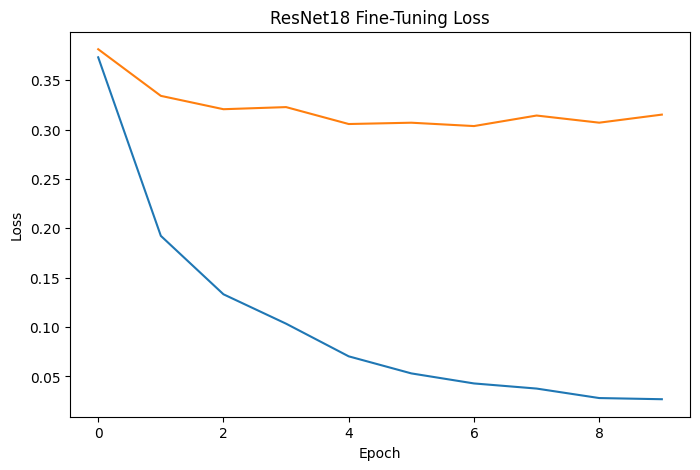

In [72]:
plt.figure(figsize=(8, 5))
plt.plot(finetune_history["train_loss"],label="Training Loss")
plt.plot(finetune_history["val_loss"],label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Fine-Tuning Loss")
plt.show()

raining loss decreases, showing the model is learning. But validation loss stays almost the same, meaning the model is not improving much on new data.

In [73]:
y_true_resnet, y_pred_resnet = get_predictions(
    resnet_model,
    test_loader,
    device
)

resnet_accuracy = accuracy_score(
    y_true_resnet,
    y_pred_resnet
)

resnet_precision = precision_score(
    y_true_resnet,
    y_pred_resnet,
    average="macro",
    zero_division=0
)

resnet_recall = recall_score(
    y_true_resnet,
    y_pred_resnet,
    average="macro",
    zero_division=0
)

resnet_f1 = f1_score(
    y_true_resnet,
    y_pred_resnet,
    average="macro",
    zero_division=0
)
print(f"Accuracy : {resnet_accuracy:.4f}")
print(f"Precision: {resnet_precision:.4f}")
print( f"Recall   : {resnet_recall:.4f}")
print(f"F1 Score : {resnet_f1:.4f}")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy : 0.8735
Precision: 0.8777
Recall   : 0.8732
F1 Score : 0.8725


In [75]:
resnet_report = classification_report(
    y_true_resnet,
    y_pred_resnet,
    target_names=classes,
    zero_division=0,
    output_dict=True
)

resnet_report_df = pd.DataFrame(resnet_report).transpose()
resnet_report_df = resnet_report_df.round(3)
resnet_report_df

,precision,recall,f1-score,support
Abyssinian,0.820,0.837,0.828,98.000
American Bulldog,0.643,0.900,0.750,100.000
American Pit Bull Terrier,0.729,0.510,0.600,100.000
Basset Hound,0.935,0.860,0.896,100.000
Beagle,0.800,0.920,0.856,100.000
Bengal,0.723,0.940,0.817,100.000
Birman,0.736,0.780,0.757,100.000
Bombay,0.867,0.966,0.914,88.000
Boxer,0.835,0.919,0.875,99.000
British Shorthair,0.941,0.800,0.865,100.000


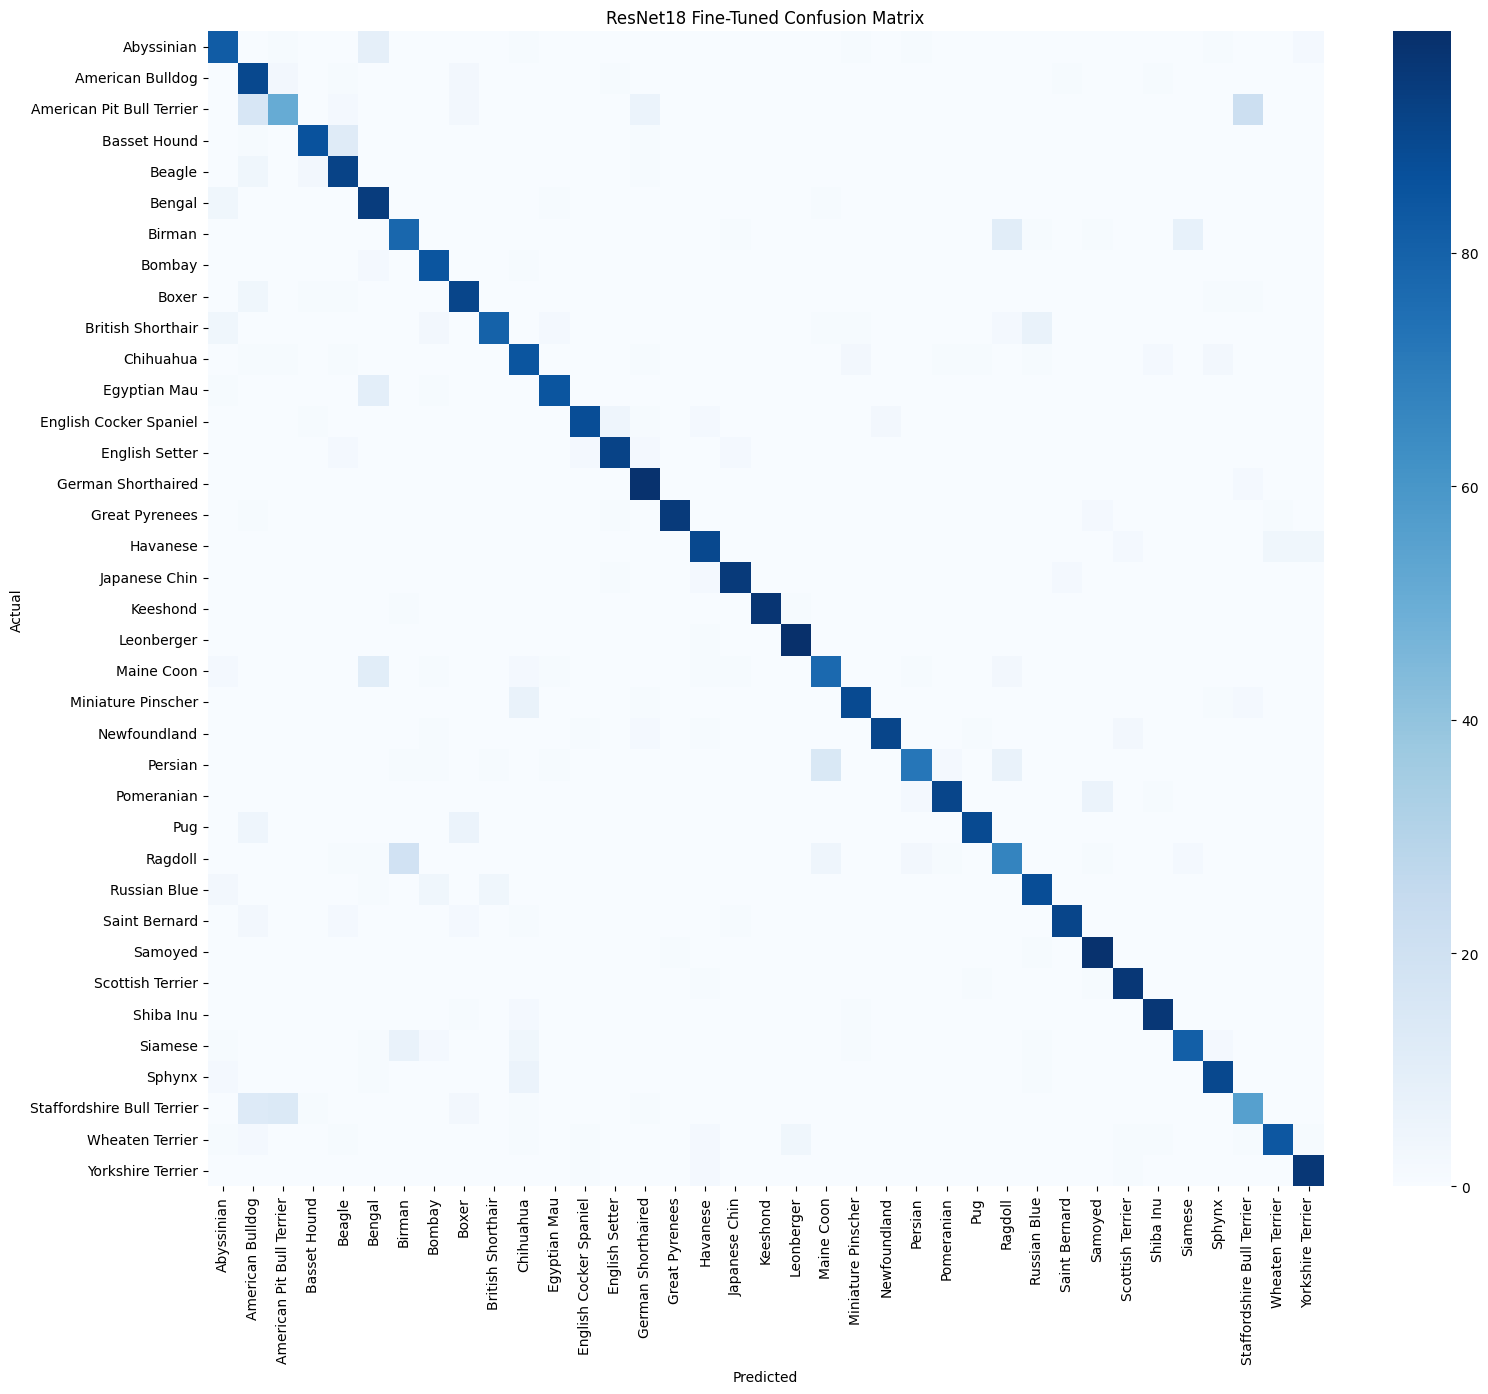

In [76]:
cm_resnet = confusion_matrix(y_true_resnet,y_pred_resnet)
plt.figure(figsize=(18, 15))
sns.heatmap(
    cm_resnet,
    annot=False,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet18 Fine-Tuned Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

ResNet18 correctly predicts most dog breeds, but it sometimes confuses one breed with another.

In [77]:
results = pd.DataFrame({
   "Model": ["Custom CNN","ResNet18 Fine-Tuned"],
   "Accuracy": [custom_accuracy,resnet_accuracy],
   "Precision": [custom_precision,resnet_precision],
   "Recall": [custom_recall,resnet_recall],
   "F1 Score": [custom_f1,resnet_f1],
   "Training Time (min)": [
        custom_training_time / 60,
        (
            feature_extraction_time +
            fine_tuning_time
        ) / 60
    ]
})


In [78]:
results

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (min)
0,Custom CNN,0.117743,0.121540,0.118095,0.09599,116.743844
1,ResNet18 Fine-Tuned,0.873535,0.877655,0.873158,0.87252,132.556790


In [79]:
experiment_results = pd.DataFrame({

    "Experiment": [
        "Custom CNN + Augmentation",
        "Custom CNN + Lower LR",
        "Custom CNN + No Augmentation",
        "ResNet18 Feature Extraction",
        "ResNet18 Fine-Tuning"
    ],

    "Model": [
        "Custom CNN",
        "Custom CNN",
        "Custom CNN",
        "ResNet18",
        "ResNet18"
    ],

    "Learning Rate": [
        0.001,
        0.0001,
        0.001,
        0.001,
        0.0001
    ],

    "Augmentation": [
        "Yes",
        "Yes",
        "No",
        "Yes",
        "Yes"
    ],

    "Training Strategy": [
        "From Scratch",
        "From Scratch",
        "From Scratch",
        "Feature Extraction",
        "Fine-Tuning"
    ]
})

experiment_results

,Experiment,Model,Learning Rate,Augmentation,Training Strategy
0,Custom CNN + Augmentation,Custom CNN,0.0010,Yes,From Scratch
1,Custom CNN + Lower LR,Custom CNN,0.0001,Yes,From Scratch
2,Custom CNN + No Augmentation,Custom CNN,0.0010,No,From Scratch
3,ResNet18 Feature Extraction,ResNet18,0.0010,Yes,Feature Extraction
4,ResNet18 Fine-Tuning,ResNet18,0.0001,Yes,Fine-Tuning


In [80]:
FINAL_MODEL_PATH = "oxford_pet_resnet18_final.pth"
torch.save(
    resnet_model.state_dict(),
    FINAL_MODEL_PATH
)
print("Model saved:",FINAL_MODEL_PATH)

Model saved: oxford_pet_resnet18_final.pth


In [81]:
config = {
    "classes": classes,
    "num_classes": NUM_CLASSES,
    "image_size": IMG_SIZE,
    "mean": mean,
    "std": std,
    "model": "ResNet18",
    "dataset": "Oxford-IIIT Pet"
}

with open("model_config.json","w") as f:
        json.dump(config,f,indent=4)
print("Configuration saved.")

Configuration saved.


In [82]:
inference_model = models.resnet18(weights=None)
inference_model.fc = nn.Linear(inference_model.fc.in_features,NUM_CLASSES)
inference_model.load_state_dict(
    torch.load(
        FINAL_MODEL_PATH,
        map_location=device
    )
)
inference_model = inference_model.to(device)
inference_model.eval()

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [83]:
inference_transform = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    )
    ])

In [89]:
sample_image, actual_label = dataset_test[0]

prediction, confidence = predict_image(sample_image)
print("Actual:", classes[actual_label])
print("Predicted:", prediction)
print("Confidence:",f"{confidence * 100:.2f}%")

Actual: Abyssinian
Predicted: Abyssinian
Confidence: 96.30%


In [88]:
def predict_image(image,model=inference_model):
    model.eval()
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    image = image.convert("RGB")
    image_tensor = inference_transform(image)
    image_tensor = image_tensor.unsqueeze(0)
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs,dim=1)
        confidence, predicted = torch.max(probabilities,1)
        predicted_class = classes[predicted.item()]
        confidence_value = confidence.item()

    return (predicted_class,confidence_value)

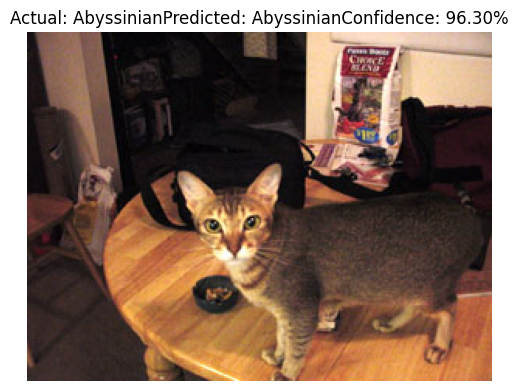

In [91]:
plt.figure(figsize=(6, 6))
plt.imshow(sample_image)
plt.title(
    f"Actual: {classes[actual_label]}"
    f"Predicted: {prediction}"
    f"Confidence: {confidence*100:.2f}%"
)
plt.axis("off")
plt.show()

In [92]:
def predict_top_classes(image):

    inference_model.eval()
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
        image = image.convert("RGB")
        image_tensor = inference_transform(image)
        image_tensor = image_tensor.unsqueeze(0)
        image_tensor = image_tensor.to(device)

    with torch.no_grad():
        outputs = inference_model(image_tensor)
        probabilities = torch.softmax(outputs,dim=1)
        probabilities = probabilities[0]
        top_probs, top_indices = torch.topk(probabilities,k=5)

    results = {}

    for prob, index in zip(top_probs,top_indices):
         results[classes[index.item()]] = (prob.item())

    return results

In [95]:
correct_indices = np.where(y_true_resnet == y_pred_resnet)[0]
print("Correct predictions:", len(correct_indices))

Correct predictions: 3205


In [96]:
incorrect_indices = np.where(y_true_resnet != y_pred_resnet)[0]
print("Incorrect predictions:",len(incorrect_indices))

Incorrect predictions: 464


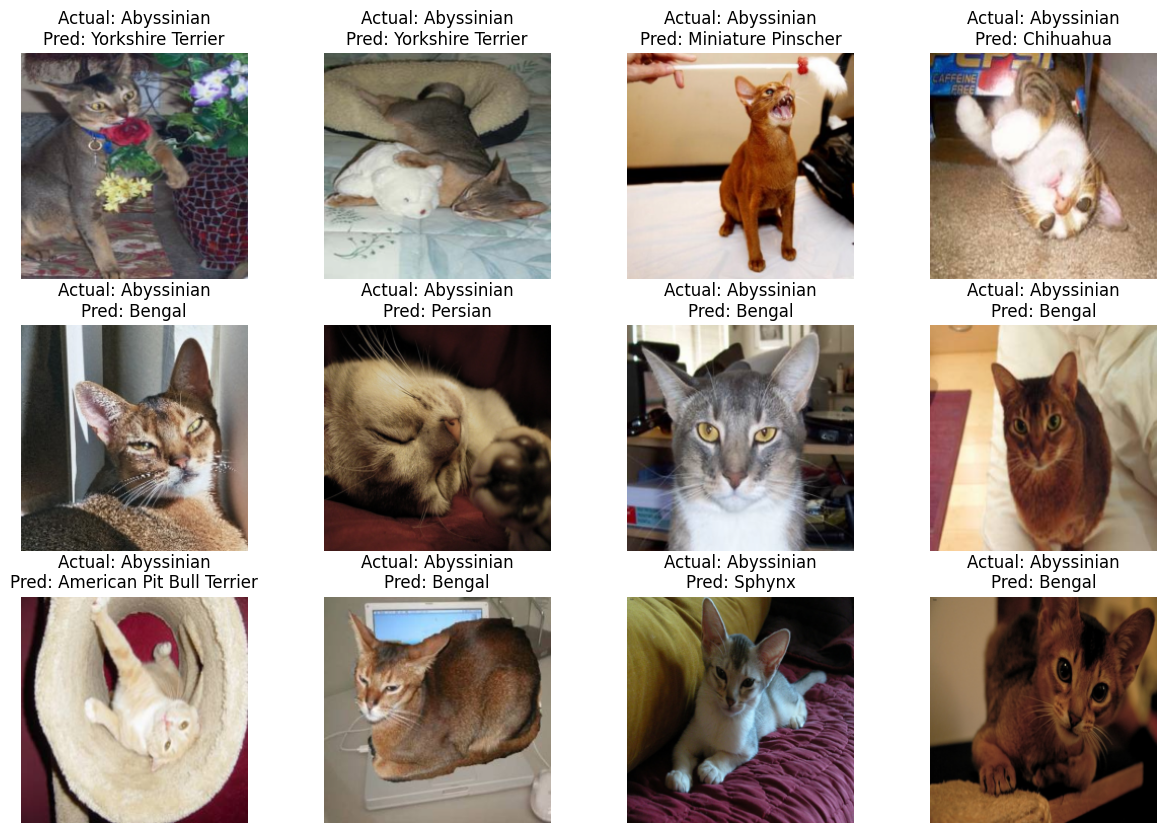

In [97]:
plt.figure(figsize=(15, 10))

for i, index in enumerate(incorrect_indices[:12]):
    image, label = test_dataset[index]
    image_display = image.permute(1, 2, 0).numpy()
    image_display = (image_display *np.array(std)) + np.array(mean)
    image_display = np.clip(image_display,0,1)
    plt.subplot(3, 4, i + 1)
    plt.imshow(image_display)
    plt.title(
        f"Actual: {classes[y_true_resnet[index]]}\n"
        f"Pred: {classes[y_pred_resnet[index]]}"
    )

    plt.axis("off")
plt.show()

In [98]:
results.to_csv("model_comparison_results.csv",index=False)
print("Results saved to model_comparison_results.csv")

Results saved to model_comparison_results.csv


In [99]:
history_df = pd.DataFrame({
    "epoch": range(1, len(finetune_history["train_loss"]) + 1),
    "train_loss": finetune_history["train_loss"],
    "val_loss": finetune_history["val_loss"],
    "train_accuracy": finetune_history["train_acc"],
    "val_accuracy": finetune_history["val_acc"]
})
history_df.to_csv("training_history.csv",index=False)
history_df.head()

,epoch,train_loss,val_loss,train_accuracy,val_accuracy
0,1,0.373131,0.381330,88.994565,87.364130
1,2,0.192332,0.334104,95.618207,89.538043
2,3,0.133156,0.320578,97.044837,90.217391
3,4,0.103390,0.322714,97.995924,90.760870
4,5,0.070324,0.305583,98.879076,91.032609
